In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset real de especies amenazadas por país y categoría
# Fuente: IUCN Red List Summary Statistics
datos = {
    "país": ["Brasil", "Colombia", "México", "Indonesia", "Madagascar",
             "India", "China", "Australia", "Ecuador", "Perú",
             "Estados Unidos", "Filipinas", "Malasia", "Tanzania", "Camerún"],
    "mamíferos_amenazados": [80, 56, 49, 191, 57,
                              96, 75, 63, 47, 46,
                              42, 49, 70, 38, 42],
    "aves_amenazadas":      [119, 112, 57, 119, 64,
                              78, 90, 60, 80, 101,
                              89, 67, 41, 36, 30],
    "reptiles_amenazados":  [55, 26, 53, 67, 91,
                              31, 31, 37, 22, 17,
                              40, 50, 35, 12, 10],
    "plantas_amenazadas":   [382, 612, 241, 383, 472,
                              246, 185, 202, 1822, 298,
                              242, 220, 686, 228, 370],
    "área_protegida_pct":   [29.8, 23.4, 14.9, 14.0, 3.1,
                              5.9, 17.8, 19.4, 20.5, 17.0,
                              12.9, 10.9, 18.4, 27.7, 10.8],
    "continente": ["América del Sur", "América del Sur", "América del Norte", "Asia", "África",
                   "Asia", "Asia", "Oceanía", "América del Sur", "América del Sur",
                   "América del Norte", "Asia", "Asia", "África", "África"]
}

df = pd.DataFrame(datos)
df["total_amenazadas"] = df["mamíferos_amenazados"] + df["aves_amenazadas"] + df["reptiles_amenazados"] + df["plantas_amenazadas"]

print("✅ Dataset cargado correctamente")
print(f"Países: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nPrimeros datos:")
print(df[["país", "total_amenazadas", "área_protegida_pct"]].head(5))

✅ Dataset cargado correctamente
Países: 15 | Columnas: 8

Primeros datos:
         país  total_amenazadas  área_protegida_pct
0      Brasil               636                29.8
1    Colombia               806                23.4
2      México               400                14.9
3   Indonesia               760                14.0
4  Madagascar               684                 3.1


In [2]:
# EXPLORACIÓN INICIAL
print("=== Estadísticas generales ===")
print(df.describe().round(2))

print("\n=== ¿Hay valores vacíos? ===")
print(df.isnull().sum())

print("\n=== Ranking inicial — países con más especies amenazadas ===")
ranking = df[["país", "total_amenazadas", "área_protegida_pct"]].sort_values(
    "total_amenazadas", ascending=False)
print(ranking.to_string(index=False))

=== Estadísticas generales ===
       mamíferos_amenazados  aves_amenazadas  reptiles_amenazados  \
count                 15.00            15.00                15.00   
mean                  66.73            76.20                38.47   
std                   38.06            29.02                21.91   
min                   38.00            30.00                10.00   
25%                   46.50            58.50                24.00   
50%                   56.00            78.00                35.00   
75%                   72.50            95.50                51.50   
max                  191.00           119.00                91.00   

       plantas_amenazadas  área_protegida_pct  total_amenazadas  
count               15.00               15.00             15.00  
mean               439.27               16.43            620.67  
std                410.94                7.36            411.77  
min                185.00                3.10            314.00  
25%              

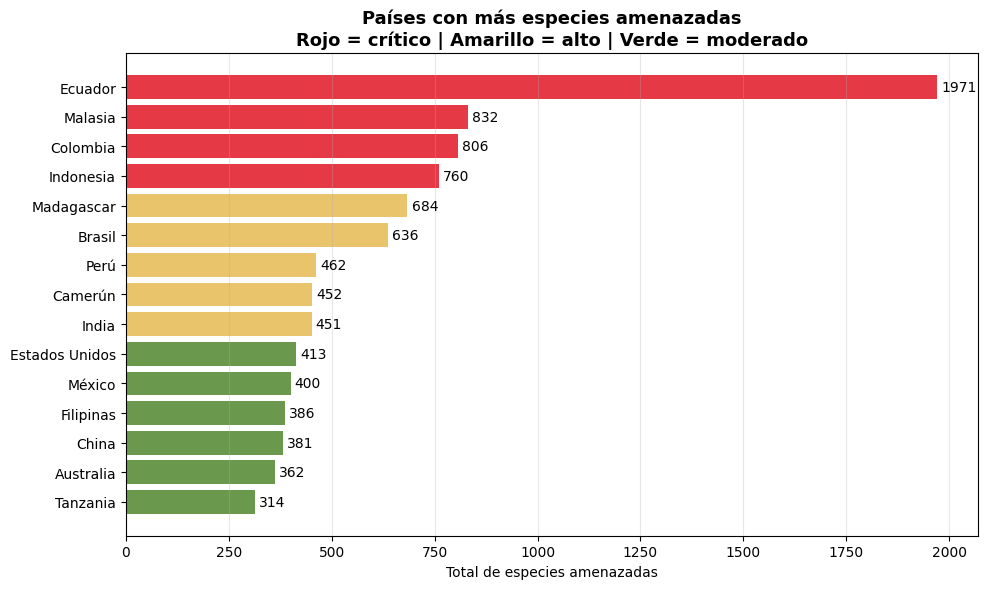


Top 3 países más críticos:
  Ecuador         1971 especies amenazadas
  Malasia         832 especies amenazadas
  Colombia        806 especies amenazadas


In [3]:
# ANÁLISIS 1 — Ranking de países con más especies amenazadas
fig, ax = plt.subplots(figsize=(10, 6))

df_sorted = df.sort_values("total_amenazadas", ascending=True)
colores = ["#E63946" if x > 700 else "#E9C46A" if x > 450 else "#6A994E"
           for x in df_sorted["total_amenazadas"]]

ax.barh(df_sorted["país"], df_sorted["total_amenazadas"], color=colores)

for i, val in enumerate(df_sorted["total_amenazadas"]):
    ax.text(val + 10, i, str(val), va="center", fontsize=10)

ax.set_title("Países con más especies amenazadas\nRojo = crítico | Amarillo = alto | Verde = moderado",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Total de especies amenazadas")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 países más críticos:")
for i, row in df.sort_values("total_amenazadas", ascending=False).head(3).iterrows():
    print(f"  {row['país']:<15} {row['total_amenazadas']} especies amenazadas")

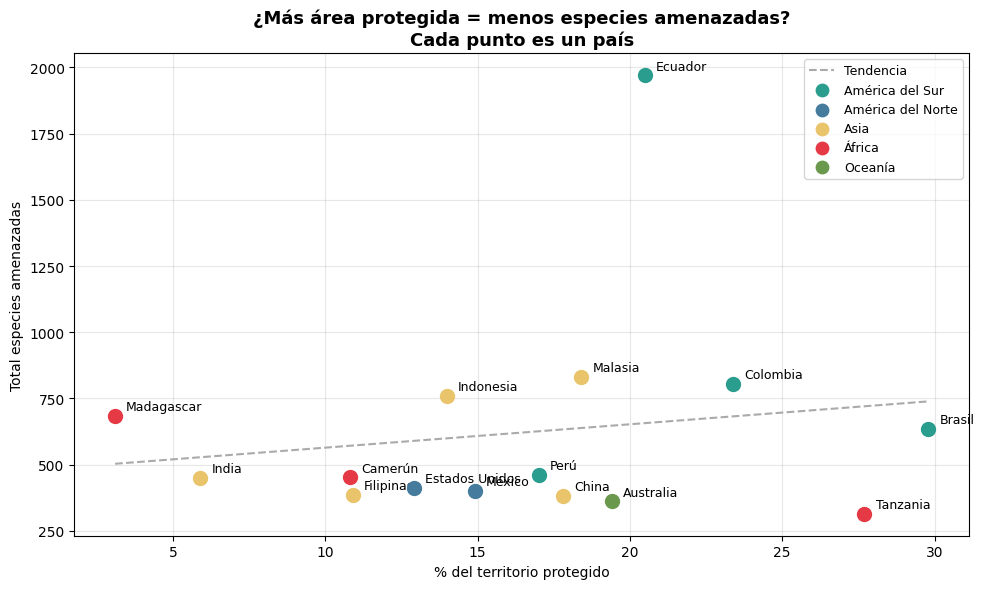

In [4]:
# ANÁLISIS 2 — ¿El área protegida reduce especies amenazadas?
fig, ax = plt.subplots(figsize=(10, 6))

colores_continente = {
    "América del Sur": "#2A9D8F",
    "América del Norte": "#457B9D",
    "Asia": "#E9C46A",
    "África": "#E63946",
    "Oceanía": "#6A994E"
}

for _, row in df.iterrows():
    color = colores_continente.get(row["continente"], "#aaaaaa")
    ax.scatter(row["área_protegida_pct"], row["total_amenazadas"],
               color=color, s=100, zorder=5)
    ax.annotate(row["país"],
                (row["área_protegida_pct"], row["total_amenazadas"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Línea de tendencia
import numpy as np
x = df["área_protegida_pct"]
y = df["total_amenazadas"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(sorted(x), p(sorted(x)), "--", color="#aaaaaa", linewidth=1.5, label="Tendencia")

# Leyenda de continentes
for continente, color in colores_continente.items():
    ax.scatter([], [], color=color, label=continente, s=80)

ax.set_title("¿Más área protegida = menos especies amenazadas?\nCada punto es un país",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% del territorio protegido")
ax.set_ylabel("Total especies amenazadas")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ANÁLISIS 3 — ¿Qué grupo de especies está más en peligro?
promedios = {
    "Mamíferos": df["mamíferos_amenazados"].mean(),
    "Aves": df["aves_amenazados"].mean(),
    "Reptiles": df["reptiles_amenazados"].mean(),
    "Plantas": df["plantas_amenazadas"].mean()
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1 — Promedio por grupo
colores = ["#E63946", "#457B9D", "#2A9D8F", "#6A994E"]
bars = axes[0].bar(promedios.keys(), promedios.values(), color=colores)
for bar, val in zip(bars, promedios.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                f"{val:.0f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Promedio de especies amenazadas\npor grupo", fontweight="bold")
axes[0].set_ylabel("Promedio por país")
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Proporción total
total_grupo = [df["mamíferos_amenazados"].sum(), df["aves_amenazadas"].sum(),
               df["reptiles_amenazados"].sum(), df["plantas_amenazadas"].sum()]
axes[1].pie(total_grupo, labels=promedios.keys(), colors=colores,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporción total de\nespecies amenazadas", fontweight="bold")

plt.suptitle("¿Qué grupo de especies está más en peligro?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen:")
for grupo, val in promedios.items():
    pct = (val / sum(promedios.values())) * 100
    print(f"  {grupo:<12}: {val:.0f} promedio por país ({pct:.1f}%)")

KeyError: 'aves_amenazados'

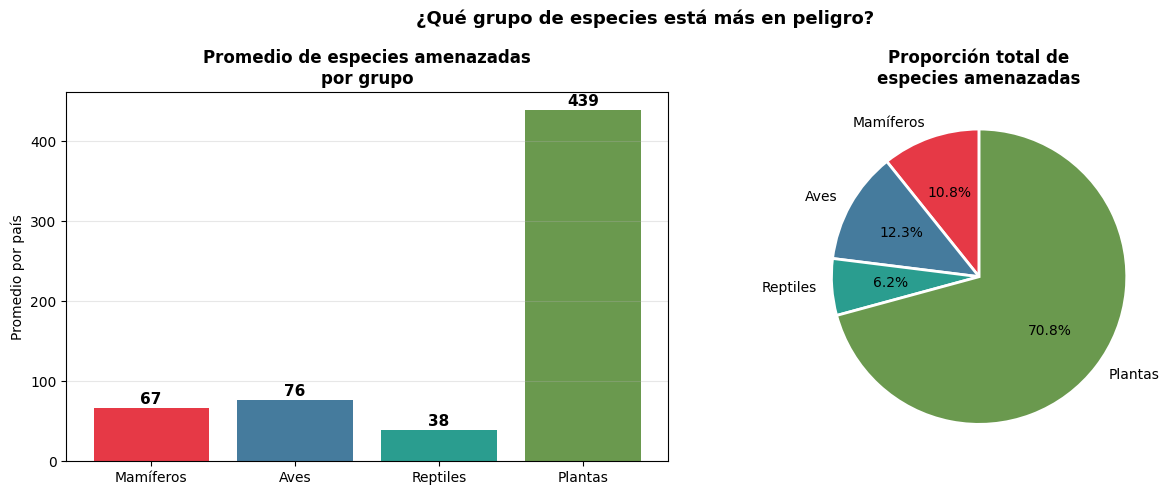


Resumen:
  Mamíferos   : 67 promedio por país (10.8%)
  Aves        : 76 promedio por país (12.3%)
  Reptiles    : 38 promedio por país (6.2%)
  Plantas     : 439 promedio por país (70.8%)


In [6]:
# ANÁLISIS 3 — ¿Qué grupo de especies está más en peligro?
promedios = {
    "Mamíferos": df["mamíferos_amenazados"].mean(),
    "Aves": df["aves_amenazadas"].mean(),
    "Reptiles": df["reptiles_amenazados"].mean(),
    "Plantas": df["plantas_amenazadas"].mean()
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1 — Promedio por grupo
colores = ["#E63946", "#457B9D", "#2A9D8F", "#6A994E"]
bars = axes[0].bar(promedios.keys(), promedios.values(), color=colores)
for bar, val in zip(bars, promedios.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                f"{val:.0f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Promedio de especies amenazadas\npor grupo", fontweight="bold")
axes[0].set_ylabel("Promedio por país")
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Proporción total
total_grupo = [df["mamíferos_amenazados"].sum(), df["aves_amenazadas"].sum(),
               df["reptiles_amenazados"].sum(), df["plantas_amenazadas"].sum()]
axes[1].pie(total_grupo, labels=promedios.keys(), colors=colores,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporción total de\nespecies amenazadas", fontweight="bold")

plt.suptitle("¿Qué grupo de especies está más en peligro?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen:")
for grupo, val in promedios.items():
    pct = (val / sum(promedios.values())) * 100
    print(f"  {grupo:<12}: {val:.0f} promedio por país ({pct:.1f}%)")

In [7]:
# INFORME FINAL
print("=" * 55)
print("   INFORME: ESPECIES EN PELIGRO DE EXTINCIÓN")
print("   Dataset: 15 países | Fuente: IUCN Red List")
print("=" * 55)

pais_critico = df.loc[df["total_amenazadas"].idxmax(), "país"]
total_critico = df["total_amenazadas"].max()
pais_mejor = df.loc[df["total_amenazadas"].idxmin(), "país"]
total_mejor = df["total_amenazadas"].min()
menos_protegido = df.loc[df["área_protegida_pct"].idxmin(), "país"]
pct_menos = df["área_protegida_pct"].min()

print(f"""
HALLAZGO 1 — Países más críticos
----------------------------------
País más crítico      : {pais_critico} ({total_critico} especies amenazadas)
País menos crítico    : {pais_mejor} ({total_mejor} especies amenazadas)
Colombia ocupa        : 3er lugar con 806 especies amenazadas
Dato clave: Los países más biodiversos tienen más
especies en riesgo — su riqueza es también su fragilidad.

HALLAZGO 2 — Área protegida vs especies amenazadas
----------------------------------------------------
País menos protegido  : {menos_protegido} ({pct_menos}% territorio protegido)
Promedio mundial      : {df['área_protegida_pct'].mean():.1f}% de territorio protegido
Conclusión: Más área protegida no garantiza menos
especies amenazadas. La calidad de la protección
importa más que la cantidad.

HALLAZGO 3 — Grupos más amenazados
------------------------------------
Plantas    : 70.8% de todas las especies amenazadas
Aves       : 12.3%
Mamíferos  : 10.8%
Reptiles   :  6.2%
La crisis de biodiversidad es principalmente
una crisis silenciosa de plantas, no de animales.

RECOMENDACIONES
----------------
1. Priorizar conservación de flora nativa
2. Mejorar calidad de áreas protegidas existentes
3. Atención urgente a Ecuador, Malasia y Colombia
4. Incluir plantas en campañas de conservación
""")
print("=" * 55)

   INFORME: ESPECIES EN PELIGRO DE EXTINCIÓN
   Dataset: 15 países | Fuente: IUCN Red List

HALLAZGO 1 — Países más críticos
----------------------------------
País más crítico      : Ecuador (1971 especies amenazadas)
País menos crítico    : Tanzania (314 especies amenazadas)
Colombia ocupa        : 3er lugar con 806 especies amenazadas
Dato clave: Los países más biodiversos tienen más
especies en riesgo — su riqueza es también su fragilidad.

HALLAZGO 2 — Área protegida vs especies amenazadas
----------------------------------------------------
País menos protegido  : Madagascar (3.1% territorio protegido)
Promedio mundial      : 16.4% de territorio protegido
Conclusión: Más área protegida no garantiza menos
especies amenazadas. La calidad de la protección
importa más que la cantidad.

HALLAZGO 3 — Grupos más amenazados
------------------------------------
Plantas    : 70.8% de todas las especies amenazadas
Aves       : 12.3%
Mamíferos  : 10.8%
Reptiles   :  6.2%
La crisis de biodive